## Plot various properties of LM events

### Import libraries

In [1]:
import pandas as pd
from obspy import read,UTCDateTime
from datetime import datetime, timedelta
import numpy as np
import os
import glob
import sys
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy.fft import fft, fftfreq

# Import functions
fxndir = '../functions/'
sys.path.insert(0,fxndir)
from moon2data import *
from moonquake_temperatures import *

### Load catalogs of LM events

#### Repeating

In [2]:
# Catalog with information by geophone
mqdir = '../catalogs/final_catalogs/LM_vs_boulder_vs_other/'
cat1_rpt = pd.read_csv(mqdir + 'A17_repeating_LM_catalog_HQ_final.csv')
cat1_rpt.drop(list(cat1_rpt.filter(regex='Unnamed|index')), axis=1, inplace=True)

# Catalog with information averaged per event
cat2_rpt = pd.read_csv(mqdir + 'A17_repeating_LM_catalog_HQ_avg_event_stats.csv')
cat2_rpt.drop(list(cat2_rpt.filter(regex='Unnamed|index')), axis=1, inplace=True)
evids_rpt = np.unique(cat2_rpt.evid.tolist())

In [3]:
len(evids_rpt)

1332

#### Isolated

In [4]:
# Catalog with information by geophone
cat1_isol = pd.read_csv(mqdir + 'A17_isolated_LM_catalog_HQ_final.csv')
cat1_isol.drop(list(cat1_isol.filter(regex='Unnamed|index')), axis=1, inplace=True)

# Catalog with information averaged per event
cat2_isol = pd.read_csv(mqdir + 'A17_isolated_LM_catalog_HQ_avg_event_stats.csv')
cat2_isol.drop(list(cat2_isol.filter(regex='Unnamed|index')), axis=1, inplace=True)
evids_isol = np.unique(cat2_isol.evid.tolist())

In [5]:
len(evids_isol)

249

### Load temperature cycle

In [6]:
tempdir = '../catalogs/temperature/'
temp_df, int_df = load_temp_cats(tempdir)

# Start and end time of one cycle
starttime_str = int_df.iloc[0]['start times']
starttime = datetime.strptime(int_df.iloc[0]['start times'],'%Y-%m-%d %H:%M:%S')
endtime_str = int_df.iloc[2]['end times']
endtime = datetime.strptime(int_df.iloc[2]['end times'],'%Y-%m-%d %H:%M:%S')

# Times and temperatures 
# One day
temp_df_day = temp_df.loc[(temp_df.Time_YMD >= starttime_str) & (temp_df.Time_YMD <= endtime_str)]
times_day = np.array(temp_df_day.Time_s.tolist())/(3600*24)
rock_temps_day = np.array(temp_df_day.T_rock_K.tolist())
reg_temps_day = np.array(temp_df_day.T_reg_K.tolist())
# Entire timeframe
temp_reg = np.array(temp_df.T_reg_K.tolist())
temp_rock = np.array(temp_df.T_rock_K.tolist())
temp_diff = temp_rock - temp_reg
time_ymd = [datetime.strptime(mqdate, '%Y-%m-%d %H:%M:%S') for mqdate in (temp_df['Time_YMD']).tolist()]

### Obtain stats

In [7]:
# Time in temperature cycle
int_days_rpt = np.array(cat2_rpt.avg_interval_day.tolist())
int_days_isol = np.array(cat2_isol.avg_interval_day.tolist())
int_days = np.concatenate([int_days_rpt,int_days_isol])

# Emergences
emergences_rpt = np.array(cat2_rpt.avg_emergence_s.tolist())
emergences_isol = np.array(cat2_isol.avg_emergence_s.tolist())

# Isolated azimuths
# Lag
cat2_isol_az = cat2_isol.loc[(cat2_isol.grade_new == 'AA') | (cat2_isol.grade_new == 'BB')]
thetas_lag_isol = np.array(cat2_isol_az.theta_mean_lag_deg.tolist())
# SNR
thetas_snr_isol = np.array(cat2_isol_az.theta_mean_snr_deg.tolist())

# Repeating
# Lag
cat2_rpt_az = cat2_rpt.loc[(cat2_rpt.grade_new == 'AA') | (cat2_rpt.grade_new == 'BB')]
thetas_lag_rpt = np.array(cat2_rpt_az.theta_mean_lag_deg.tolist())
# SNR
thetas_snr_rpt = np.array(cat2_rpt_az.theta_mean_snr_deg.tolist())

### Bin azimuths

In [8]:
# Bin azimuths from lag
theta_bins = np.linspace(0,2*np.pi,30)
# Isolated
theta_mean_radii_lag_isol = (thetas_lag_isol * np.pi) / 180
counts_lag_isol, histbins_lag_isol = np.histogram(theta_mean_radii_lag_isol, bins=theta_bins)
histbins_lag_isol = histbins_lag_isol[:-1]
# Repeating
theta_mean_radii_lag_rpt = (thetas_lag_rpt * np.pi) / 180
counts_lag_rpt, histbins_lag_rpt = np.histogram(theta_mean_radii_lag_rpt, bins=theta_bins)
histbins_lag_rpt = histbins_lag_rpt[:-1]

# Bin azimuths from SNR pick
# Isolated
theta_mean_radii_snr_isol = (thetas_snr_isol * np.pi) / 180
counts_snr_isol, histbins_snr_isol = np.histogram(theta_mean_radii_snr_isol, bins=theta_bins)
histbins_snr_isol = histbins_snr_isol[:-1]
# Repeating
theta_mean_radii_snr_rpt = (thetas_snr_rpt * np.pi) / 180
counts_snr_rpt, histbins_snr_rpt = np.histogram(theta_mean_radii_snr_rpt, bins=theta_bins)
histbins_snr_rpt = histbins_snr_rpt[:-1]

## Stack frequency spectra of LM events

### Inputs to obtain waveforms

In [9]:
parentdir = '/data/ytamama/Apollo17/LSPE_data/sac_volts_ds/'
minfreq = 3
maxfreq = ''
befwin = 15
aftwin = 60

### Stack frequency spectra of repeating LM events

In [10]:
T = 1/117.6
first1 = 1
first2 = 1
first3 = 1
first4 = 1
num1 = 0
num2 = 0
num3 = 0
num4 = 0

# Iterate through events
for r in np.arange(0,len(cat1_rpt)):
    
    # Obtain trace
    row1 = cat1_rpt.iloc[r]
    arrtime = datetime.strptime(row1.picktime_SNR, '%Y-%m-%d %H:%M:%S.%f')
    geonum = row1.geophone
    st = moon2sac(arrtime,geonum,befwin,aftwin,minfreq,maxfreq,parentdir)
    trdata = st.traces[0].data
    
    # Normalize each FFT with respect to # samples
    N = len(trdata)
    trdata_fft_real_rpt = np.abs(fft(trdata).real[0:N//2]) / N
    
    # Which geophone?
    if geonum == 1:
        if first1 == 1:
            trdata1_fft_real_rpt = trdata_fft_real_rpt.copy()
            first1 = 0
            trdata1 = trdata.copy()
        else:
            trdata1_fft_real_rpt += trdata_fft_real_rpt.copy()
        num1 += 1
    elif geonum == 2:
        if first2 == 1:
            trdata2_fft_real_rpt = trdata_fft_real_rpt.copy()
            first2 = 0
            trdata2 = trdata.copy()
        else:
            trdata2_fft_real_rpt += trdata_fft_real_rpt.copy()
        num2 += 1
    elif geonum == 3:
        if first3 == 1:
            trdata3_fft_real_rpt = trdata_fft_real_rpt.copy()
            first3 = 0
            trdata3 = trdata.copy()
        else:
            trdata3_fft_real_rpt += trdata_fft_real_rpt.copy()
        num3 += 1
    elif geonum == 4: 
        if first4 == 1:
            trdata4_fft_real_rpt = trdata_fft_real_rpt.copy()
            first4 = 0
            trdata4 = trdata.copy()
        else:
            trdata4_fft_real_rpt += trdata_fft_real_rpt.copy()
        num4 += 1

        
# Frequencies
# Geophone 1
N = len(trdata1)
T = 1/117.6
freqs1_rpt = fftfreq(N, T)[:N//2]

# Geophone 2
N = len(trdata2)
freqs2_rpt = fftfreq(N, T)[:N//2]

# Geophone 3
N = len(trdata3)
freqs3_rpt = fftfreq(N, T)[:N//2]

# Geophone 4
N = len(trdata4)
freqs4_rpt = fftfreq(N, T)[:N//2]

### Stack frequency spectra of isolated LM events

In [11]:
T = 1/117.6
first1 = 1
first2 = 1
first3 = 1
first4 = 1
num1 = 0
num2 = 0
num3 = 0
num4 = 0

# Iterate through events
for r in np.arange(0,len(cat1_isol)):
    
    # Obtain trace
    row1 = cat1_isol.iloc[r]
    arrtime = datetime.strptime(row1.picktime_SNR, '%Y-%m-%d %H:%M:%S.%f')
    geonum = row1.geophone
    st = moon2sac(arrtime,geonum,befwin,aftwin,minfreq,maxfreq,parentdir)
    trdata = st.traces[0].data
    
    # Normalize each FFT with respect to # samples
    N = len(trdata)
    trdata_fft_real_isol = np.abs(fft(trdata).real[0:N//2]) / N
    
    # Which geophone?
    if geonum == 1:
        if first1 == 1:
            trdata1_fft_real_isol = trdata_fft_real_isol.copy()
            first1 = 0
            trdata1 = trdata.copy()
        else:
            trdata1_fft_real_isol += trdata_fft_real_isol.copy()
        num1 += 1
    elif geonum == 2:
        if first2 == 1:
            trdata2_fft_real_isol = trdata_fft_real_isol.copy()
            first2 = 0
            trdata2 = trdata.copy()
        else:
            trdata2_fft_real_isol += trdata_fft_real_isol.copy()
        num2 += 1
    elif geonum == 3:
        if first3 == 1:
            trdata3_fft_real_isol = trdata_fft_real_isol.copy()
            first3 = 0
            trdata3 = trdata.copy()
        else:
            trdata3_fft_real_isol += trdata_fft_real_isol.copy()
        num3 += 1
    elif geonum == 4: 
        if first4 == 1:
            trdata4_fft_real_isol = trdata_fft_real_isol.copy()
            first4 = 0
            trdata4 = trdata.copy()
        else:
            trdata4_fft_real_isol += trdata_fft_real_isol.copy()
        num4 += 1

        
# Frequencies
# Geophone 1
N = len(trdata1)
T = 1/117.6
freqs1_isol = fftfreq(N, T)[:N//2]

# Geophone 2
N = len(trdata2)
freqs2_isol = fftfreq(N, T)[:N//2]

# Geophone 3
N = len(trdata3)
freqs3_isol = fftfreq(N, T)[:N//2]

# Geophone 4
N = len(trdata4)
freqs4_isol = fftfreq(N, T)[:N//2]

## Put everything in one plot

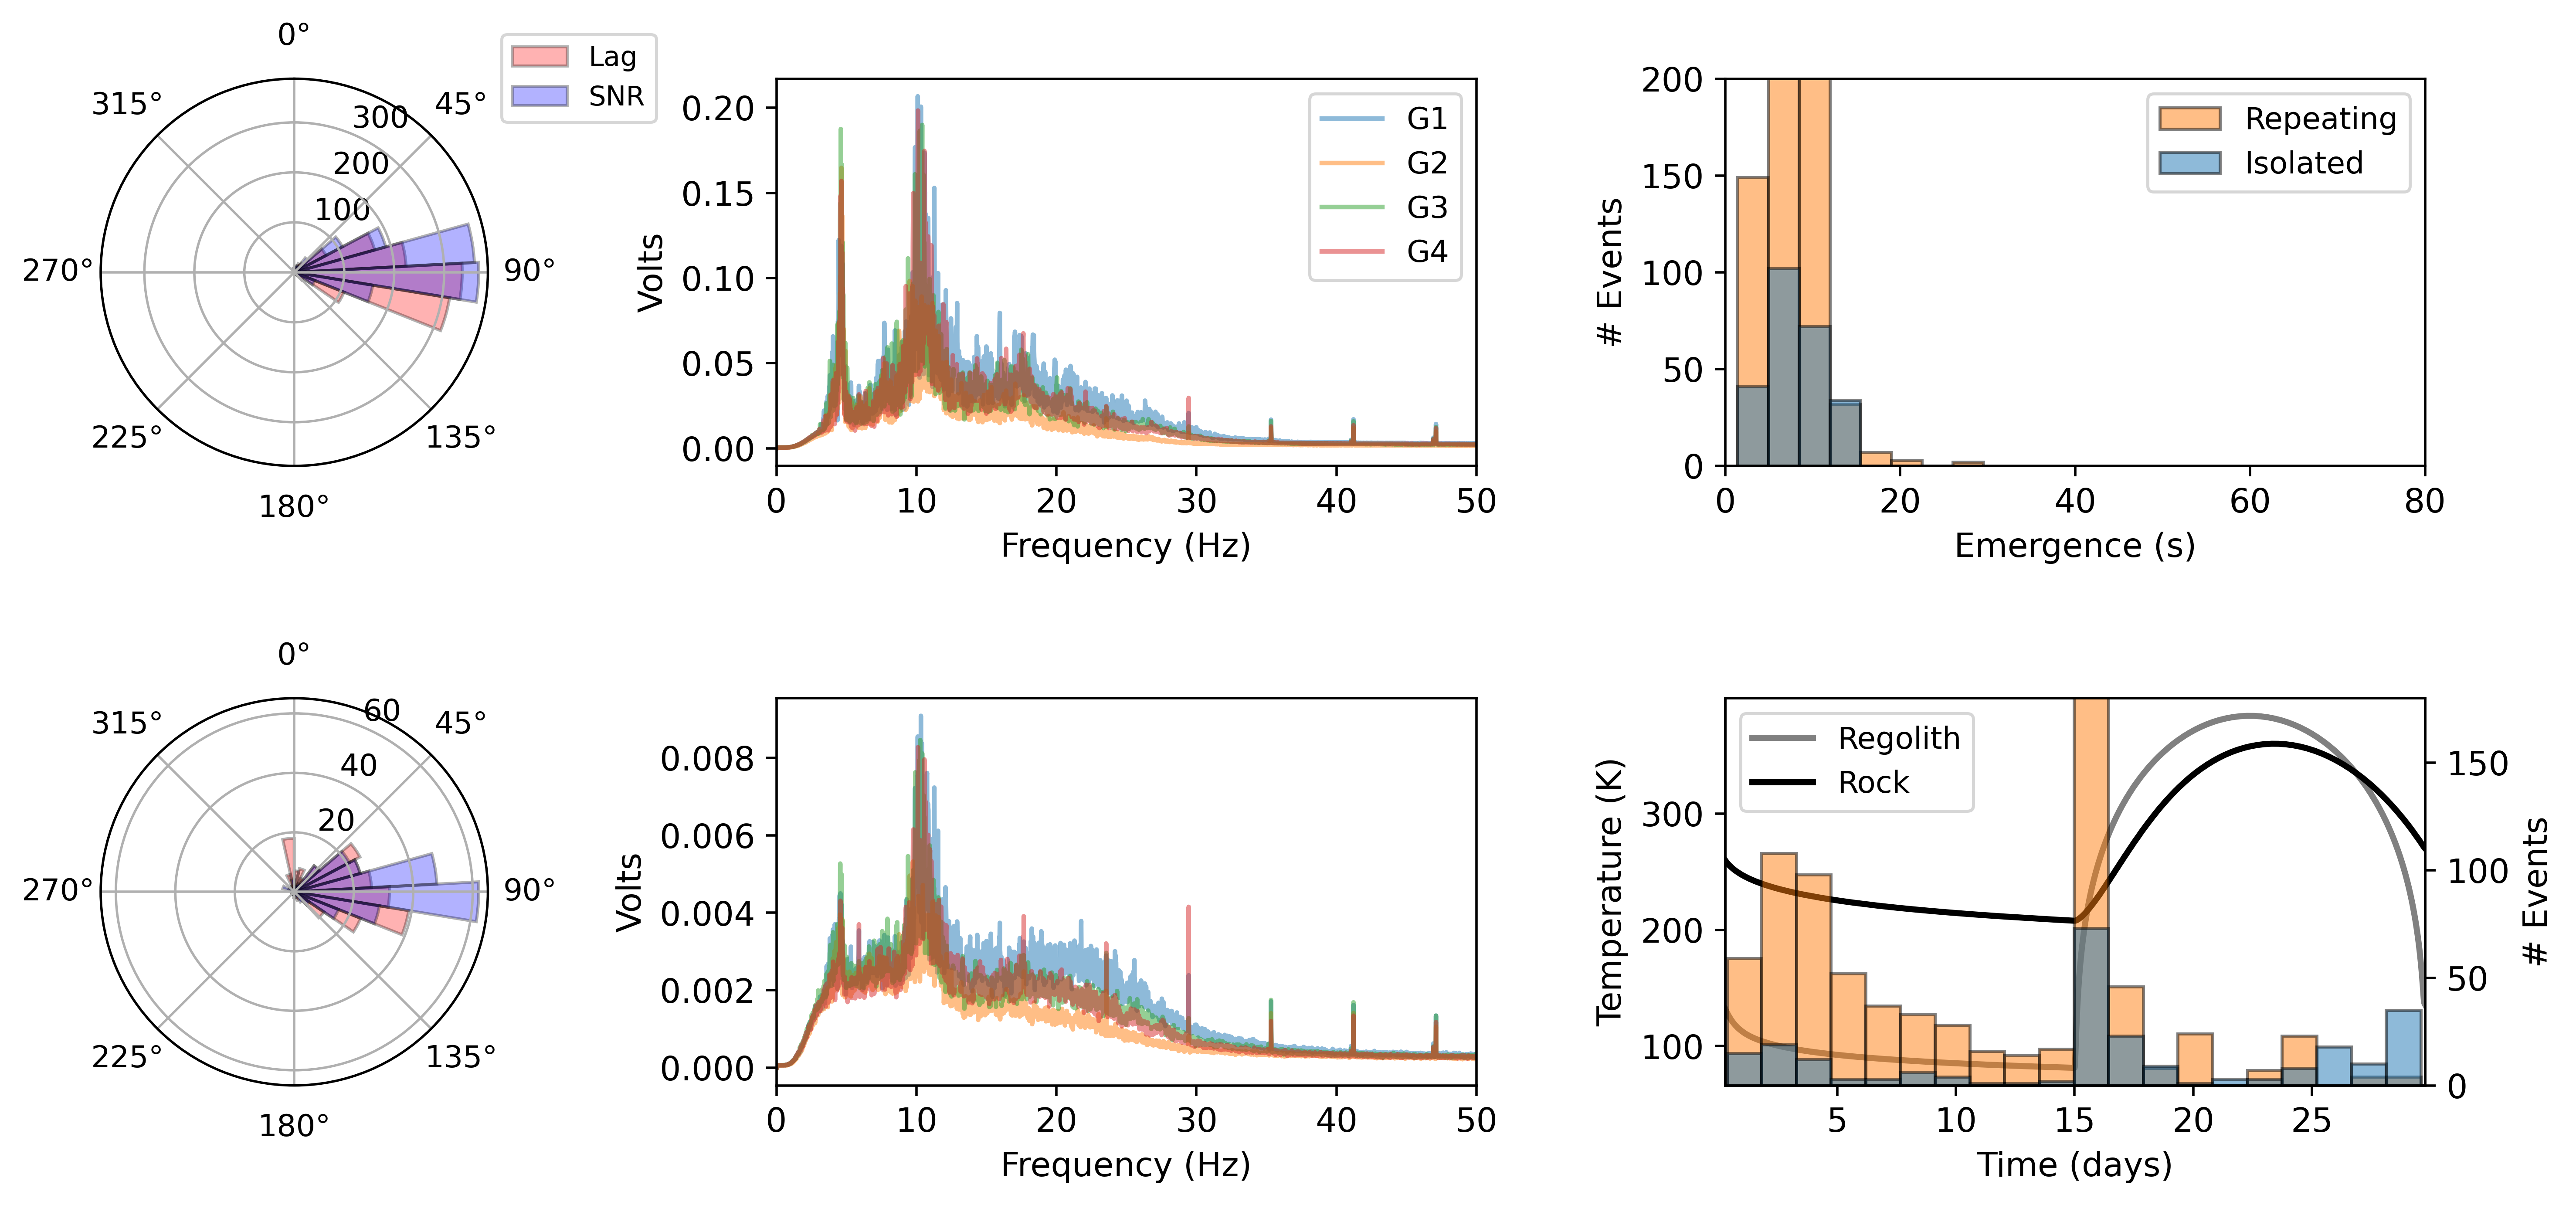

In [12]:
# Initialize figure
fig = plt.figure(figsize=(14., 6.), dpi=500)
gs = gridspec.GridSpec(2, 3, width_ratios=(1,1.5,1.5)) 

# Repeating azimuths
ax_az_rpt = fig.add_subplot(gs[0, 0], projection='polar')
ax_az_rpt.bar(histbins_lag_rpt, counts_lag_rpt, width = histbins_lag_rpt[1] - histbins_lag_rpt[0], align='edge', color='red', edgecolor='black', alpha=0.3, label='Lag')
ax_az_rpt.bar(histbins_snr_rpt, counts_snr_rpt, width = histbins_snr_rpt[1] - histbins_snr_rpt[0], align='edge', color='blue', edgecolor='black', alpha=0.3, label='SNR')
ax_az_rpt.set_theta_zero_location("N")
ax_az_rpt.set_theta_direction(-1)
ax_az_rpt.legend(loc='upper right',bbox_to_anchor=(1.47,1.15),fontsize=9)

# Repeating spectra
ax_freq_rpt = fig.add_subplot(gs[0, 1])
ax_freq_rpt.plot(freqs1_rpt,trdata1_fft_real_rpt,color='C0',alpha=0.5,label='G1')
ax_freq_rpt.plot(freqs2_rpt,trdata2_fft_real_rpt,color='C1',alpha=0.5,label='G2')
ax_freq_rpt.plot(freqs3_rpt,trdata3_fft_real_rpt,color='C2',alpha=0.5,label='G3')
ax_freq_rpt.plot(freqs4_rpt,trdata4_fft_real_rpt,color='C3',alpha=0.5,label='G4')
ax_freq_rpt.set_xlim([0,50])
ax_freq_rpt.tick_params(axis='both',labelsize=11)
ax_freq_rpt.set_ylabel('Volts',fontsize=11)
ax_freq_rpt.set_xlabel('Frequency (Hz)',fontsize=11)
ax_freq_rpt.legend(loc='upper right')

# Isolated azimuths
ax_az_isol = fig.add_subplot(gs[1, 0], projection='polar')
ax_az_isol.bar(histbins_lag_isol, counts_lag_isol, width = histbins_lag_isol[1] - histbins_lag_isol[0], align='edge', color='red', edgecolor='black', alpha=0.3, label='Lag')
ax_az_isol.bar(histbins_snr_isol, counts_snr_isol, width = histbins_snr_isol[1] - histbins_snr_isol[0], align='edge', color='blue', edgecolor='black', alpha=0.3, label='SNR')
ax_az_isol.set_theta_zero_location("N")
ax_az_isol.set_theta_direction(-1)

# Isolated spectra
ax_freq_isol = fig.add_subplot(gs[1, 1])
ax_freq_isol.plot(freqs1_isol,trdata1_fft_real_isol,color='C0',alpha=0.5,label='G1')
ax_freq_isol.plot(freqs2_isol,trdata2_fft_real_isol,color='C1',alpha=0.5,label='G2')
ax_freq_isol.plot(freqs3_isol,trdata3_fft_real_isol,color='C2',alpha=0.5,label='G3')
ax_freq_isol.plot(freqs4_isol,trdata4_fft_real_isol,color='C3',alpha=0.5,label='G4')
ax_freq_isol.set_xlim([0,50])
ax_freq_isol.tick_params(axis='both',labelsize=11)
ax_freq_isol.set_ylabel('Volts',fontsize=11)
ax_freq_isol.set_xlabel('Frequency (Hz)',fontsize=11)

# Temperatures
ax_temp = fig.add_subplot(gs[1, 2])
ax_temp.plot(times_day, reg_temps_day, color='grey', linewidth=2, label='Regolith')
ax_temp.plot(times_day, rock_temps_day, color='black', linewidth=2, label='Rock')
ax_temp.set_xlim([min(times_day),max(times_day)])
ax_temp.legend(loc='upper left',fontsize=10)
ax_temp2 = ax_temp.twinx()
bins = np.histogram(np.hstack((int_days_isol,int_days_rpt)), bins=20)[1]
ax_temp2.hist(int_days_rpt, color='C1',alpha=0.5, edgecolor='black', bins=bins, label='Repeating')
ax_temp2.hist(int_days_isol, color='C0',alpha=0.5, edgecolor='black', bins=bins, label='Isolated')
ax_temp2.set_xlim([min(times_day),max(times_day)])
ax_temp2.set_ylim([0,180])
ax_temp.set_ylabel('Temperature (K)',fontsize=11)
ax_temp.set_xlabel('Time (days)',fontsize=11)
ax_temp.tick_params(axis='both',labelsize=11)
ax_temp2.set_ylabel('# Events',fontsize=11)
ax_temp2.tick_params(axis='both',labelsize=11)

# Emergences
ax_emg = fig.add_subplot(gs[0, 2])
bins = np.histogram(np.hstack((emergences_isol,emergences_rpt)), bins=8)[1]
ax_emg.hist(emergences_rpt, color='C1',alpha=0.5, edgecolor='black', bins=bins, label='Repeating')
ax_emg.hist(emergences_isol, color='C0',alpha=0.5, edgecolor='black', bins=bins, label='Isolated')
ax_emg.set_xlim([0, 80])
ax_emg.set_ylim([0, 200])
ax_emg.legend(loc='upper right')
ax_emg.set_ylabel('# Events',fontsize=11)
ax_emg.set_xlabel('Emergence (s)',fontsize=11)
ax_emg.tick_params(axis='both',labelsize=11)
plt.subplots_adjust(wspace = 0.4, hspace = 0.6)

### Plot frequency spectra separated by geophone

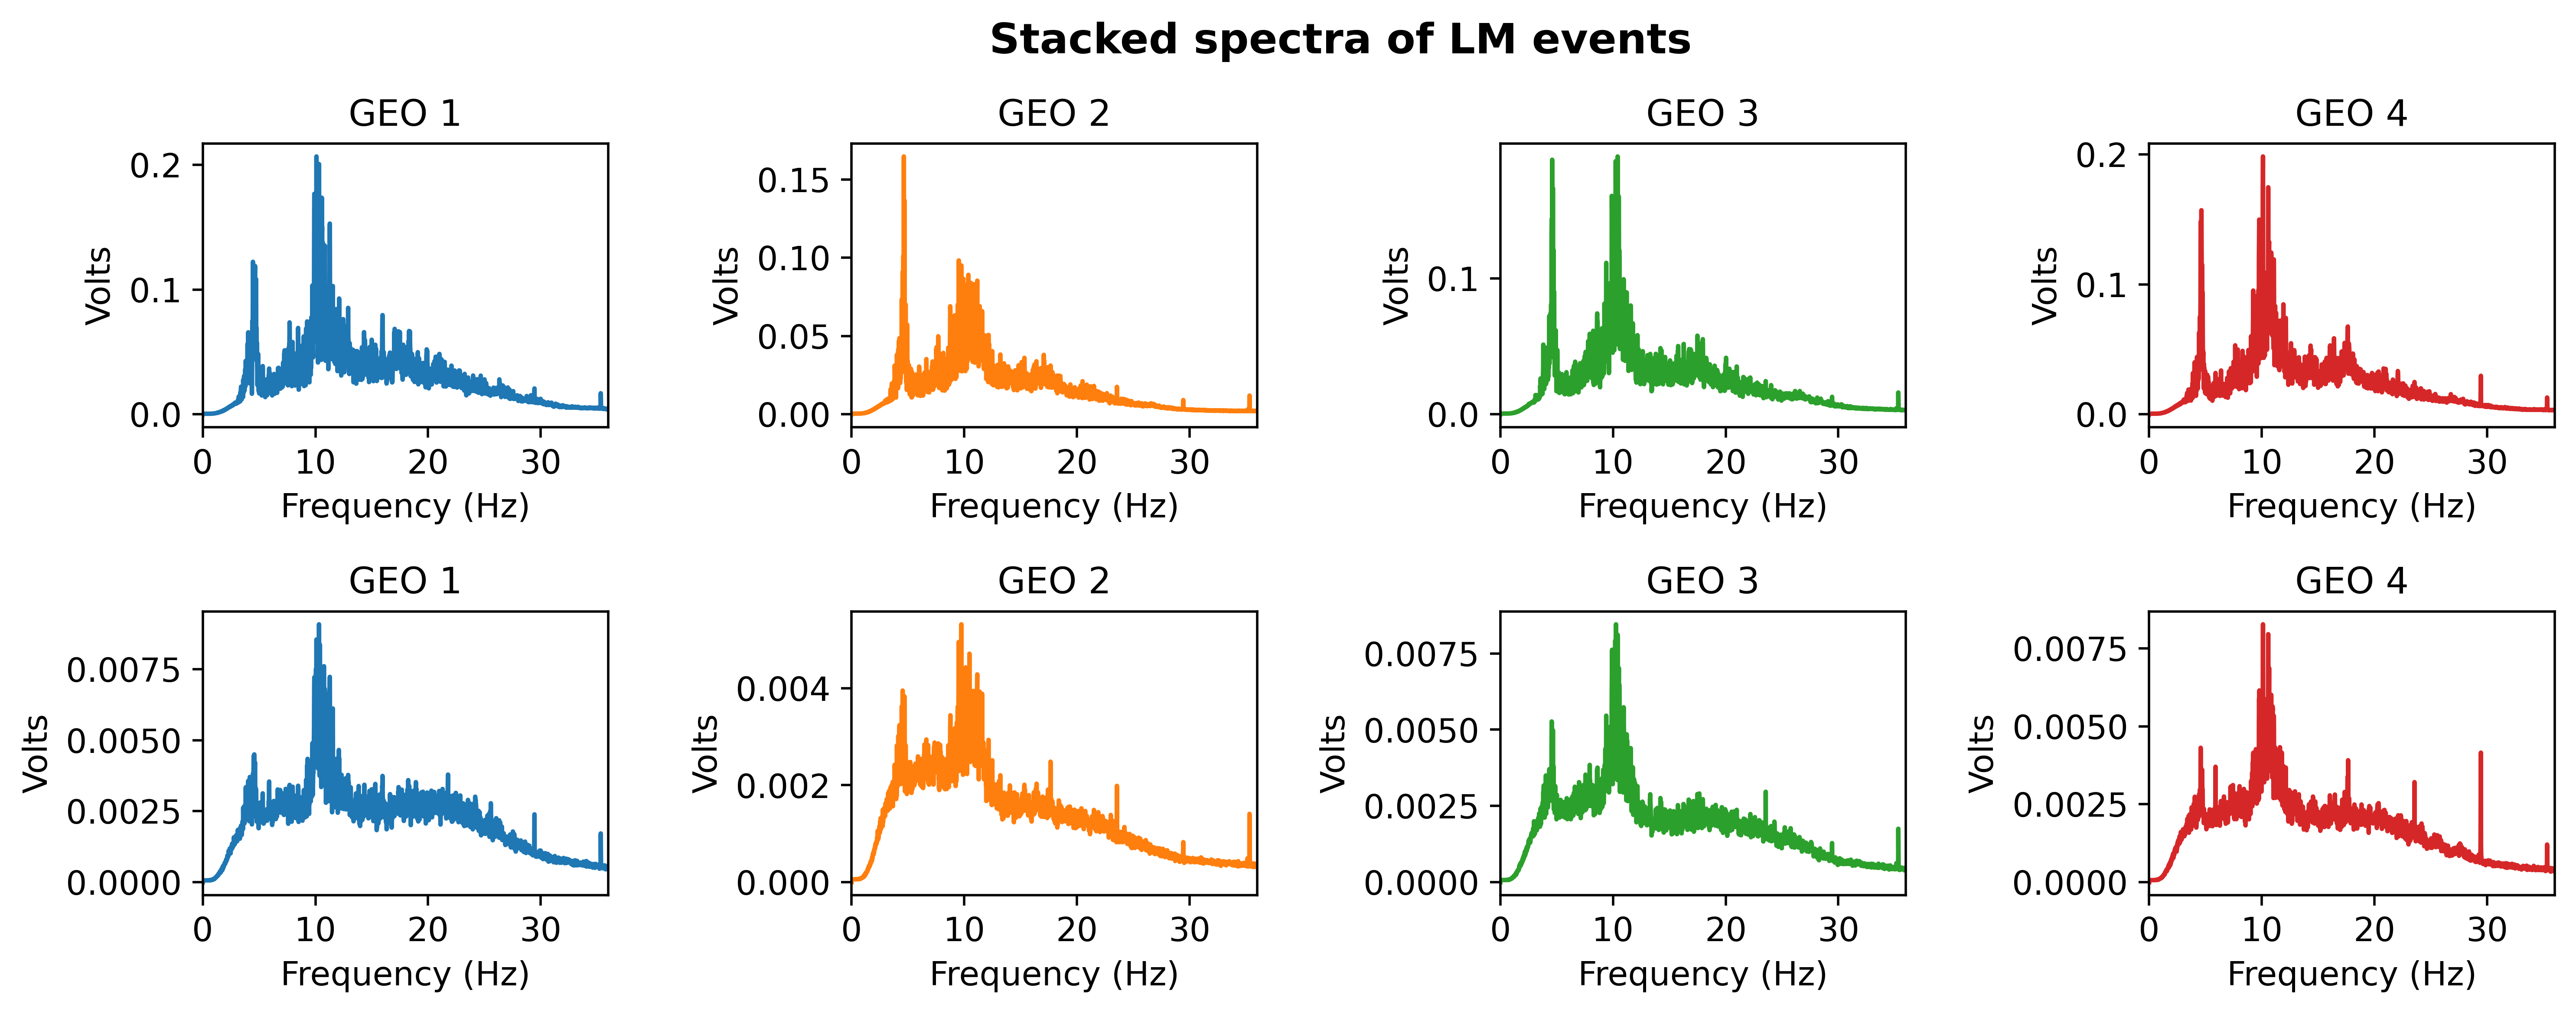

In [13]:
fig = plt.figure(figsize=(14., 4.5), dpi=500)
gs = gridspec.GridSpec(2, 4) 

### Repeating
# Geophone 1
ax1r = fig.add_subplot(gs[0, 0])
ax1r.plot(freqs1_rpt,trdata1_fft_real_rpt,color='C0')
ax1r.set_xlim([0,36])
ax1r.set_xlabel('Frequency (Hz)',fontsize=11)
ax1r.set_ylabel('Volts',fontsize=11)
ax1r.set_title('GEO 1')
ax1r.tick_params(axis='both',labelsize=11)

# Geophone 2
ax2r = fig.add_subplot(gs[0, 1])
ax2r.plot(freqs2_rpt,trdata2_fft_real_rpt,color='C1')
ax2r.set_xlim([0,36])
ax2r.set_xlabel('Frequency (Hz)',fontsize=11)
ax2r.set_ylabel('Volts',fontsize=11)
ax2r.set_title('GEO 2')
ax2r.tick_params(axis='both',labelsize=11)

# Geophone 3
ax3r = fig.add_subplot(gs[0, 2])
ax3r.plot(freqs3_rpt,trdata3_fft_real_rpt,color='C2')
ax3r.set_xlim([0,36])
ax3r.set_xlabel('Frequency (Hz)',fontsize=11)
ax3r.set_ylabel('Volts',fontsize=11)
ax3r.set_title('GEO 3')
ax3r.tick_params(axis='both',labelsize=11)

# Geophone 4
ax4r = fig.add_subplot(gs[0, 3])
ax4r.plot(freqs4_rpt,trdata4_fft_real_rpt,color='C3')
ax4r.set_xlim([0,36])
ax4r.set_xlabel('Frequency (Hz)',fontsize=11)
ax4r.set_ylabel('Volts',fontsize=11)
ax4r.set_title('GEO 4')
ax4r.tick_params(axis='both',labelsize=11)

### Isolated
# Geophone 1
ax1i = fig.add_subplot(gs[1, 0])
ax1i.plot(freqs1_isol,trdata1_fft_real_isol,color='C0')
ax1i.set_xlim([0,36])
ax1i.set_xlabel('Frequency (Hz)',fontsize=11)
ax1i.set_ylabel('Volts',fontsize=11)
ax1i.set_title('GEO 1')
ax1i.tick_params(axis='both',labelsize=11)

# Geophone 2
ax2i = fig.add_subplot(gs[1, 1])
ax2i.plot(freqs2_isol,trdata2_fft_real_isol,color='C1')
ax2i.set_xlim([0,36])
ax2i.set_xlabel('Frequency (Hz)',fontsize=11)
ax2i.set_ylabel('Volts',fontsize=11)
ax2i.set_title('GEO 2')
ax2i.tick_params(axis='both',labelsize=11)

# Geophone 3
ax3i = fig.add_subplot(gs[1, 2])
ax3i.plot(freqs3_isol,trdata3_fft_real_isol,color='C2')
ax3i.set_xlim([0,36])
ax3i.set_xlabel('Frequency (Hz)',fontsize=11)
ax3i.set_ylabel('Volts',fontsize=11)
ax3i.set_title('GEO 3')
ax3i.tick_params(axis='both',labelsize=11)

# Geophone 4
ax4i = fig.add_subplot(gs[1, 3])
ax4i.plot(freqs4_isol,trdata4_fft_real_isol,color='C3')
ax4i.set_xlim([0,36])
ax4i.set_xlabel('Frequency (Hz)',fontsize=11)
ax4i.set_ylabel('Volts',fontsize=11)
ax4i.set_title('GEO 4')
ax4i.tick_params(axis='both',labelsize=11)

# Adjust
plt.suptitle('Stacked spectra of LM events',fontweight='bold',fontsize=14,y=1.005)
plt.subplots_adjust(wspace = 0.6, hspace = 0.65)